In [1]:
import sys
sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob
from functools import partial
from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

from jug.engine.session import TimingSession

from ATLAS.data import PTA_Data
from ATLAS.psd_functions import *
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS import parameterized
from ATLAS.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel, reparametrise
from ATLAS.signals.timing.base import setup_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils
from ATLAS import pulsar

# import MultiHMCGibbs

from ATLAS.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [3]:
from enterprise.pulsar import Pulsar

In [4]:
pnames = ['B1855+09', 'B1937+21', 
'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 
'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [5]:
parfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/par/*.par'))
timfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [6]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [7]:
assert len(parfiles) == len(pnames)

In [8]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [9]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))

# with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [10]:
with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
# psrs = [psr for psr in psrs if psr.name != 'J1713+0747' and psr.name != 'B1937+21' ]
psrs = psrs[:1]

In [11]:
with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [12]:
len(psrs)

1

In [13]:
# chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
# psrs = psrs[chosen_pidx :chosen_pidx +1]
# chosen_pidx 

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [15]:
from enterprise.pulsar import FeatherPulsar

In [4]:
feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
psrs = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs.append(psr)

with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochasti

In [10]:
# psrs = psrs[0:1]

# Data Construction

In [14]:
data = PTA_Data(psrs, 
                fixed_res = False,
                marg_timing = False, 
                diag_white_cov = False,
                linear_timing = True,
                )
raw_res = jnp.concat(data.raw_residuals)

## Timing Model

In [15]:
SAMPLE = [psrs[pidx].fitpars[1:] for pidx in range(data.npsrs)]
for i, sublist in enumerate(SAMPLE):
    for j, s in enumerate(sublist):
        SAMPLE[i][j] = s.replace('A1DOT', 'XDOT')

In [16]:
tm_model = build_multi_psr_timing_model(parfiles[:1], 
                                        timfiles[:1], 
                                        SAMPLE[:], 
                                        load_how_many_in_parallel = 10,
                                        data = data)
data.add_timing_design_matrix(tm_model.Mmats)

Loading the par and tim files...:   0%|          | 0/1 [00:00<?, ?it/s]

/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 71 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'gps2utc.clk': 14 TOA(s) before clock data start (MJD 50169.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)


In [17]:
z_tm = {}
for pidx in range(data.npsrs):
    z_tm.update({f'z_{k};{pidx}': 1 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE[pidx]})
z_tm 

{'z_PX;0': Array(-1.37421246, dtype=float64),
 'z_ELONG;0': Array(1.15826657, dtype=float64),
 'z_ELAT;0': Array(-1.79756316, dtype=float64),
 'z_PMELONG;0': Array(-1.54036415, dtype=float64),
 'z_PMELAT;0': Array(0.00505355, dtype=float64),
 'z_F0;0': Array(0.06839166, dtype=float64),
 'z_F1;0': Array(-0.09244198, dtype=float64),
 'z_DMX_0001;0': Array(1.90211895, dtype=float64),
 'z_DMX_0002;0': Array(0.38652328, dtype=float64),
 'z_DMX_0003;0': Array(0.00179989, dtype=float64),
 'z_DMX_0004;0': Array(0.48139156, dtype=float64),
 'z_DMX_0005;0': Array(-0.12618333, dtype=float64),
 'z_DMX_0006;0': Array(0.12269918, dtype=float64),
 'z_DMX_0007;0': Array(0.28373769, dtype=float64),
 'z_DMX_0008;0': Array(1.0009333, dtype=float64),
 'z_DMX_0009;0': Array(-0.47490024, dtype=float64),
 'z_DMX_0010;0': Array(-1.49600698, dtype=float64),
 'z_DMX_0011;0': Array(-0.51848953, dtype=float64),
 'z_DMX_0012;0': Array(1.02486765, dtype=float64),
 'z_DMX_0013;0': Array(1.23585708, dtype=float64),
 

In [18]:
z_tm_concat = jnp.array(list(z_tm.values()))
z_tm_concat.shape

(165,)

In [19]:
tm_model.residuals(z_tm_concat), tm_model.residuals(z_tm_concat).shape

(Array([-5.89738421e-06, -6.04196602e-06, -5.16280958e-06, ...,
        -2.38755544e-06, -2.67388198e-06, -2.10300614e-06], dtype=float64),
 (7758,))

In [20]:
%timeit tm_model.residuals(z_tm_concat)

29 μs ± 175 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [21]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

165

## White Noise Model

In [22]:
wn_model = WhiteCov(data = data, stabelize_TNT = True)

  0%|          | 0/1 [00:00<?, ?it/s]

### Initial white noise guess

In [23]:
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

In [24]:
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
wn_lower_bound[:5], wn_upper_bound[:5]

(Array([ 0.01,  0.01,  0.01,  0.01, -9.  ], dtype=float64),
 Array([10., 10., 10., 10., -5.], dtype=float64))

## Red Noise Model

In [25]:
non_gwb_nfreqs = 30
gwb_nfreqs = 14

In [26]:
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# sig_dm = Red(name='dm',
#             psd_function = partial(powerlaw),
#             nfreqs=non_gwb_nfreqs,
#             lower_bound_psd = jnp.array([-18, 0.]),
#             upper_bound_psd = jnp.array([-11, 7.0]),
#             data = data,
#             use_pulsar_tspan = False)

# sig_cor = Correlated(name='cor',
#             psd_function = partial(gwb_free_spectrum),
#             orf_function = hd_orf,
#             nfreqs=gwb_nfreqs,
#             lower_bound_psd = jnp.ones(gwb_nfreqs) * -9,
#             upper_bound_psd = jnp.ones(gwb_nfreqs) * -2,
#             data = data)

In [34]:
sig = SuperSignal(signal_list = [sig_unc],
                signal_combination_string = "ltm|unc->unc",
                data=data,
)
# sig = SuperSignal(signal_list = [sig_unc],
#                 signal_combination_string = "ltm|unc -> unc",
#                 data=data,
# )

In [35]:
x0 = sig.model.make_initial_guess(jrandom.key(12742)) #red noise model params
phi0 = sig.model.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 1), (2,))

### `sig.get_helpers` updates the white noise covaraince matrix

In [36]:
helpers = sig.get_helpers(reff = raw_res, 
                        white_noise_params = theta0_wn, 
                        #red_noise_basis = sig.get_Fmat_concat
                                        )
helpers[0].shape, helpers[1].shape

((1, 61, 61), (1, 61))

In [37]:
# %timeit sig.get_helpers(reff = raw_res, white_noise_params = theta0_wn)

# Likelihood

### Reparameterized likelihood

In [38]:
z0 = jrandom.normal(jrandom.key(108), shape = (sig.npsrs, sig.nmodes)) # re-parameterized coefficients

In [39]:
lnprob0, coeff0 = sig.lnposterior_reparam(helpers = helpers, 
                                            red_params = x0, 
                                            z = z0)
lnprob0

Array(100757.03090721, dtype=float64)

In [40]:
# lnprob0, coeff0 = sig.lnposterior_partial_marg_reparam(helpers = helpers, 
#                                             red_params = x0, 
#                                             z = z0)
# lnprob0

In [41]:
# %timeit sig.lnposterior_reparam(helpers = helpers,  red_params = x0, z = z0)

In [42]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 1000).expand([tm_param_dim]))
    stochastic_res = tm_model.residuals(z_tm_concat)

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(wn_lower_bound, wn_upper_bound))

    # Update the white noise covaraince matrix
    helpers_now = sig.get_helpers(reff = stochastic_res, white_noise_params=theta_wn)
    # helpers_now = helpers

    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(sig.model.lower_prior_lim_all, 
                                           sig.model.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))

    # numpyro.deterministic('coeff', coeff)

In [43]:
nuts_kernel = numpyro.infer.NUTS(
    model=model,
)

mcmc = numpyro.infer.MCMC(
    sampler=nuts_kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

warmup:   2%|█▍                                                                                 | 89/5000 [02:54<3:16:50,  2.40s/it, 1023 steps of size 1.66e-03. acc. prob=0.75]

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


sample: 100%|█████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [17:35<00:00,  4.74it/s, 63 steps of size 9.86e-02. acc. prob=0.90]


## Blocked Gibbs

In [88]:
site = tuple(['z_tm_concat'])  # convert list -> tuple, no extra wrapping
kernel = MultiHMCGibbsWithAnalytic(
        [numpyro.infer.NUTS(
                model=model,
                # dense_mass=[site],
                adapt_mass_matrix=True,
                # inverse_mass_matrix={site: tm_model.aux_list[0]['mle']['cov']}
                ),
        numpyro.infer.NUTS(model), 
        ],
        
        [
        ['z_tm_concat'],
        ['theta_wn', 'xs', 'z_a']
        ]
    )

# kernel = NUTS(model, max_tree_depth=8, target_accept_prob=0.8, dense_mass=False)

In [89]:
mcmc = numpyro.infer.MCMC(
    sampler=kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

sample: 100%|████████████████████████████████████████████████████████████████████| 5000/5000 [16:54<00:00,  4.93it/s, 31/63 steps of size 1.60e-01/6.31e-02. acc. prob=0.94/0.96]


In [44]:
x0.shape

(2,)

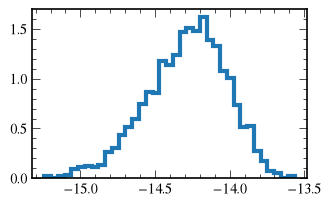

In [46]:
plt.hist(samples['xs'][:, 0], **hist_settings)
plt.show()